In [2]:
import os
import shutil
# Paths
base_image_folder = '/kaggle/input/images/images'
annotation_path = '/kaggle/input/train-test/binary_relevance_labels.xlsx'

# Destination folder to store all images
merged_folder = '/kaggle/working/merged_images'

# Create destination folder if it doesn't exist
os.makedirs(merged_folder, exist_ok=True)

# Traverse through subfolders
for folder_name in sorted(os.listdir(base_image_folder)):
    folder_path = os.path.join(base_image_folder, folder_name)

    # Ensure it's a directory
    if os.path.isdir(folder_path):
        for file_name in os.listdir(folder_path):
            src_file = os.path.join(folder_path, file_name)
            dst_file = os.path.join(merged_folder, file_name)  # ✅ Use original name

            # Check for overwrite
            if os.path.exists(dst_file):
                print(f"⚠️ Skipping duplicate: {file_name}")
                continue

            shutil.copy2(src_file, dst_file)

print("✅ All images merged into:", merged_folder)


✅ All images merged into: /kaggle/working/merged_images


# Scene Annotation of IAPRTC12 dataset

# Mapping the taxonmy with the corel5k dataset labels
# Assigning the scene taxonmy by using frequency dominant rule

In [3]:
import pandas as pd
from collections import Counter

# Paths
mapping_file = "/kaggle/input/assign-taxonomy-per-labels/label_taxonomy_mapping.csv"
image_file = "/kaggle/input/class-labels-id/IAPRTC12_class_labels.xlsx"

# Load mapping file (label → taxonomy)
df_mapping = pd.read_csv(mapping_file)
df_mapping['label'] = df_mapping['label'].str.strip().str.lower()
label_to_taxonomy = dict(zip(df_mapping['label'], df_mapping['taxonomy']))

# Load image labels
df_images = pd.read_excel(image_file, sheet_name="Image_Labels")

# Split label strings into list
df_images['label_list'] = df_images['label_names'].str.split(',')

# Function to map labels to taxonomies
def map_taxonomies(label_list):
    mapped = []
    for lbl in label_list:
        key = lbl.strip().lower()
        if key not in label_to_taxonomy:
            print(f"⚠️ Missing in mapping: {lbl}")   # Debugging
        mapped.append(label_to_taxonomy.get(key, "CHECK_MAPPING"))
    return mapped

# Function to find dominant taxonomy + count
def dominant_taxonomy_info(taxonomy_list):
    if not taxonomy_list:
        return ("CHECK_MAPPING", 0)
    count = Counter(taxonomy_list)
    dominant, freq = count.most_common(1)[0]
    return (dominant, freq)

# Map labels → taxonomies
df_images['taxonomies'] = df_images['label_list'].apply(map_taxonomies)

# Assign dominant taxonomy and its count
df_images[['dominant_taxonomy', 'dominant_count']] = df_images['taxonomies'].apply(
    lambda x: pd.Series(dominant_taxonomy_info(x))
)

# Save results
df_images.to_csv("images_with_taxonomies.csv", index=False)

# Preview
print(df_images[['file_name', 'label_names', 'taxonomies', 'dominant_taxonomy', 'dominant_count']].head())


  file_name                                        label_names  \
0    25.jpg  branch, building, car, cloud, couple-of-person...   
1    26.jpg  building, car, cloud, group-of-persons, palm, ...   
2    28.jpg                                cloud, hill, statue   
3    32.jpg                                city, edifice, hill   
4    38.jpg                                   cloud, waterfall   

                                          taxonomies  \
0  [Botanical_Elements, metropolitan_infrastructu...   
1  [metropolitan_infrastructure, Motorsport_Vehic...   
2  [Scenic_Sunset, Landscape_Features_in_Scotland...   
3  [cityscape, Architectural_and _Sculptural Elem...   
4                         [Scenic_Sunset, landscape]   

             dominant_taxonomy  dominant_count  
0           Botanical_Elements               2  
1  metropolitan_infrastructure               1  
2                Scenic_Sunset               1  
3                    cityscape               1  
4                Scen

In [4]:
import os
import shutil
import pandas as pd
from sklearn.model_selection import train_test_split

# Paths
csv_path = "/kaggle/working/images_with_taxonomies.csv"
images_dir = "/kaggle/working/merged_images"   # where all images are stored
output_dir = "/kaggle/working/dataset/"

# Read CSV
df = pd.read_csv(csv_path)

# Step 0: Handle rare classes (only 1 sample → assign to train)
rare_classes = df['dominant_taxonomy'].value_counts()[lambda x: x == 1].index
rare_df = df[df['dominant_taxonomy'].isin(rare_classes)]
rest_df = df[~df['dominant_taxonomy'].isin(rare_classes)]

# Step 1: Split rest into Train+Val (80%) and Test (20%)
train_val_df, test_df = train_test_split(
    rest_df,
    test_size=0.2,
    stratify=rest_df['dominant_taxonomy'],
    random_state=42
)

# Step 2: Handle rare classes in train+val
rare_train_val = rare_df.copy()
train_val_df = pd.concat([train_val_df, rare_train_val])

# Step 3: Split Train+Val into Train (70%) and Val (10%) relative to full dataset
rare_classes_tv = train_val_df['dominant_taxonomy'].value_counts()[lambda x: x == 1].index
rare_df_tv = train_val_df[train_val_df['dominant_taxonomy'].isin(rare_classes_tv)]
rest_df_tv = train_val_df[~train_val_df['dominant_taxonomy'].isin(rare_classes_tv)]

train_df, val_df = train_test_split(
    rest_df_tv,
    test_size=0.125,  # 0.125 of 0.8 ≈ 0.1 of total
    stratify=rest_df_tv['dominant_taxonomy'],
    random_state=42
)

# Add rare samples back to train
train_df = pd.concat([train_df, rare_df_tv])

# Function to save images
def save_images(dataframe, split):
    for _, row in dataframe.iterrows():
        file_name = row['file_name']
        taxonomy = row['dominant_taxonomy']
        
        # Create directory for taxonomy
        split_dir = os.path.join(output_dir, split, taxonomy)
        os.makedirs(split_dir, exist_ok=True)
        
        # Copy image
        src = os.path.join(images_dir, file_name)
        dst = os.path.join(split_dir, file_name)
        if os.path.exists(src):  
            shutil.copy(src, dst)

# Save train, val, test sets
save_images(train_df, "train")
save_images(val_df, "val")
save_images(test_df, "test")

# Save CSVs for reference
train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

print("✅ Dataset prepared in:", output_dir)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


✅ Dataset prepared in: /kaggle/working/dataset/
Train: 12309, Val: 1759, Test: 3517


In [5]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

# Paths
output_dir = "/kaggle/working/dataset"

# Image generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.2
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Data loaders
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_dir, "train"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical"
)

# Use train's class indices for all splits
classes = list(train_generator.class_indices.keys())

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_dir, "val"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    classes=classes   # force same classes as train
)

test_generator = val_datagen.flow_from_directory(
    os.path.join(output_dir, "test"),
    target_size=(224, 224),
    batch_size=32,
    class_mode="categorical",
    shuffle=False,
    classes=classes   # force same classes as train
)

# Now build model with correct number of classes
num_classes = len(classes)
# Load ResNet50 base (pretrained on ImageNet)
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation="relu")(x)
preds = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=preds)


# Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Train model
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


2025-09-09 07:07:11.841016: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1757401632.036562      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1757401632.089234      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found 12309 images belonging to 39 classes.
Found 1759 images belonging to 39 classes.
Found 3517 images belonging to 39 classes.


I0000 00:00:1757401645.488602      36 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1757401698.347911     144 service.cc:148] XLA service 0x7b0384002f70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1757401698.348691     144 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1757401702.973812     144 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/385 ━━━━━━━━━━━━━━━━━━━━ 7:43:16 72s/step - accuracy: 0.0312 - loss: 3.8492

I0000 00:00:1757401721.829704     144 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


385/385 ━━━━━━━━━━━━━━━━━━━━ 248s 457ms/step - accuracy: 0.4105 - loss: 2.0289 - val_accuracy: 0.0603 - val_loss: 3.3621
Epoch 2/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 147s 381ms/step - accuracy: 0.5606 - loss: 1.3469 - val_accuracy: 0.3178 - val_loss: 2.2680
Epoch 3/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 145s 378ms/step - accuracy: 0.6266 - loss: 1.1368 - val_accuracy: 0.5122 - val_loss: 1.6245
Epoch 4/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 147s 380ms/step - accuracy: 0.6671 - loss: 0.9837 - val_accuracy: 0.5054 - val_loss: 1.7218
Epoch 5/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 149s 388ms/step - accuracy: 0.7248 - loss: 0.8081 - val_accuracy: 0.5099 - val_loss: 1.7892
Epoch 6/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 150s 389ms/step - accuracy: 0.7632 - loss: 0.6900 - val_accuracy: 0.4935 - val_loss: 1.8537
Epoch 7/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 148s 384ms/step - accuracy: 0.8081 - loss: 0.5717 - val_accuracy: 0.4696 - val_loss: 2.0756
Epoch 8/10
385/385 ━━━━━━━━━━━━━━━━━━━━ 148s 385ms/step - accuracy: 0.8310 - loss: 0.48

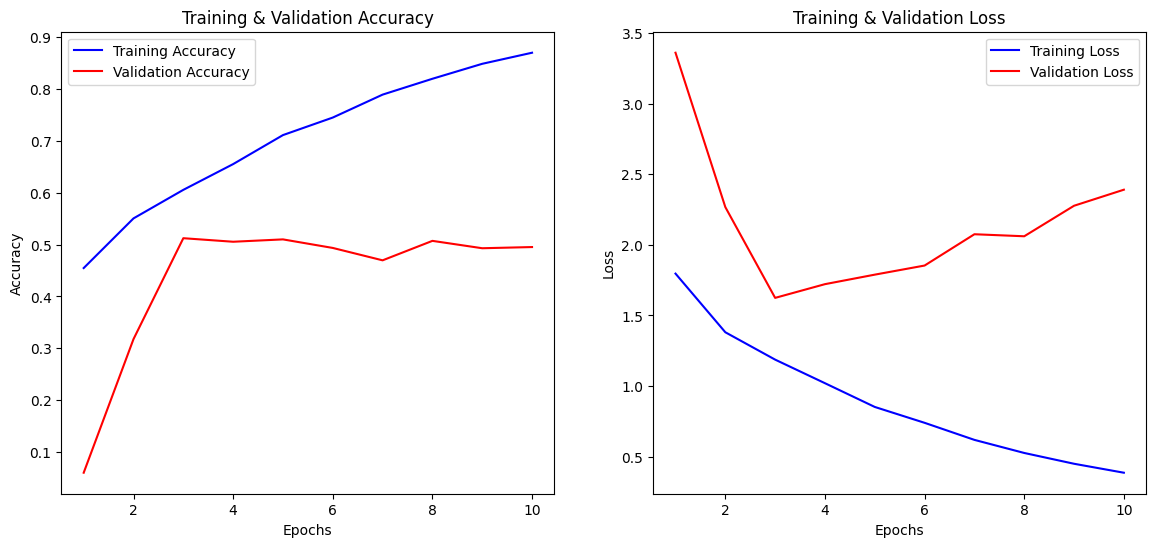

In [7]:
import matplotlib.pyplot as plt

# Extract training history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


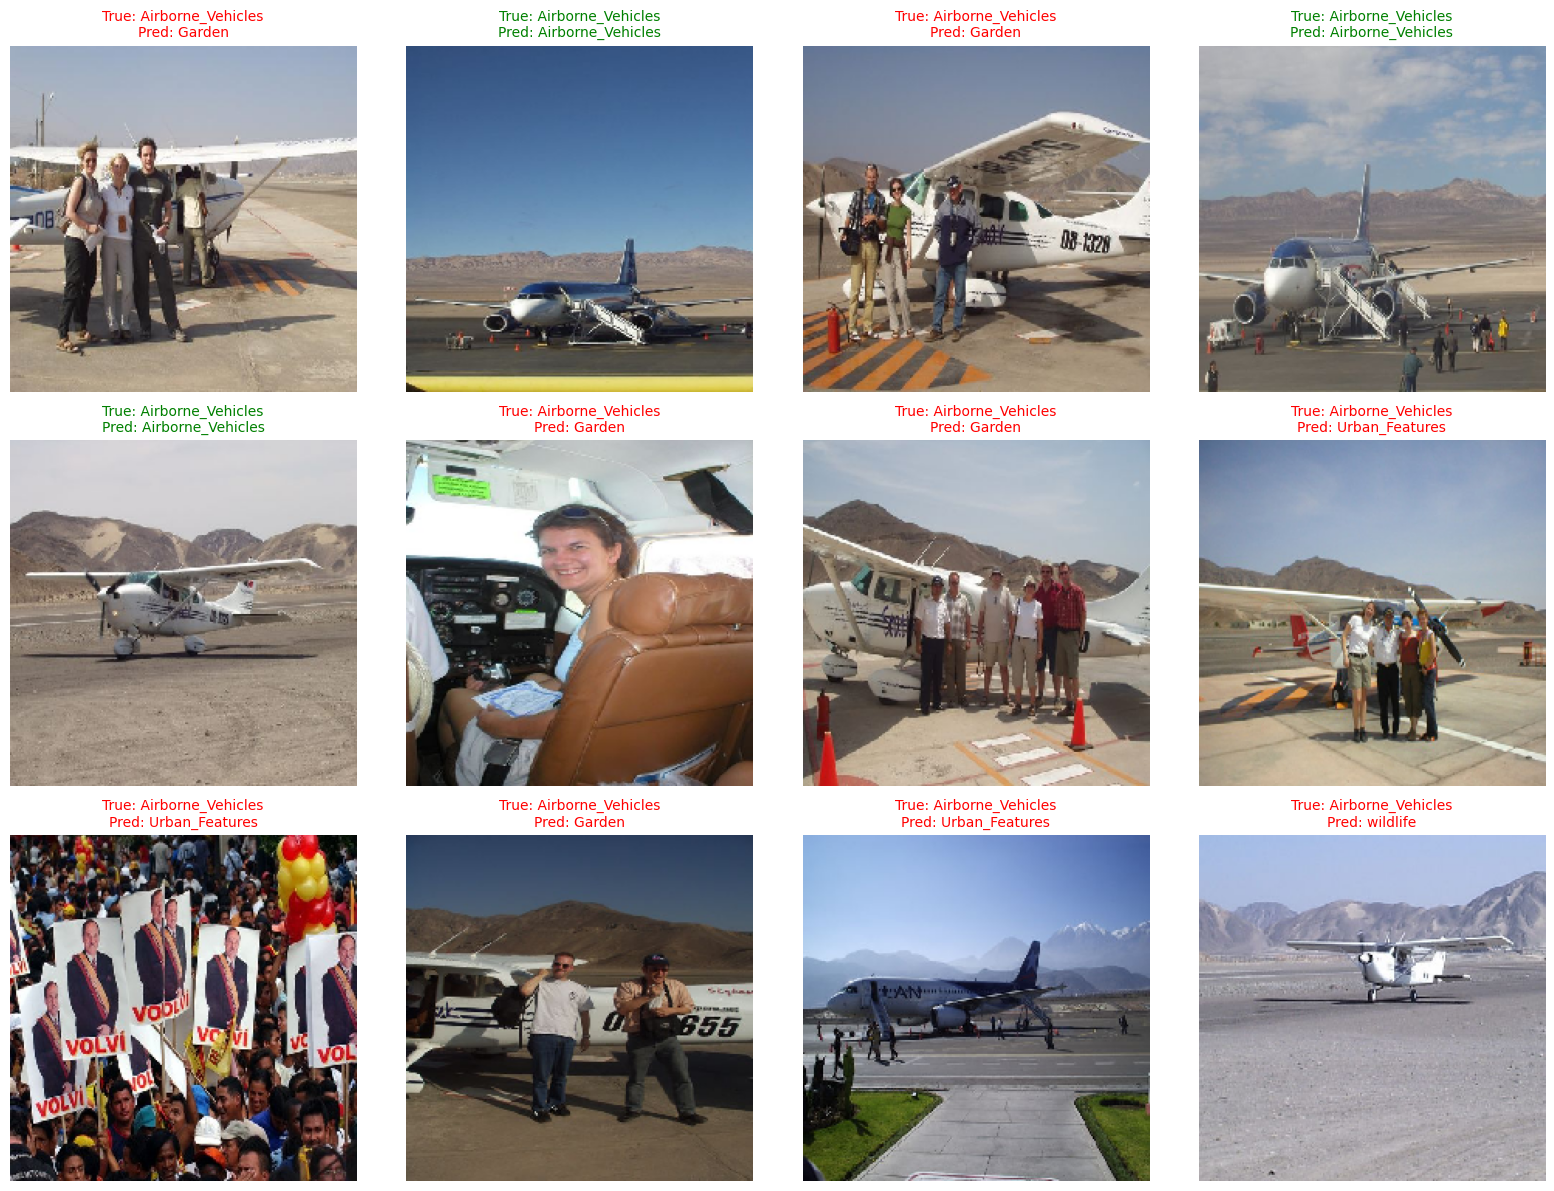

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Fetch a batch of test images
x_batch, y_batch = next(test_generator)

# Get predictions
preds = model.predict(x_batch)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(y_batch, axis=1)

# Class labels
class_labels = list(test_generator.class_indices.keys())

# Plot sample images
plt.figure(figsize=(16, 12))
for i in range(12):  # show 12 samples
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_batch[i])
    plt.axis("off")
    true_label = class_labels[true_classes[i]]
    pred_label = class_labels[pred_classes[i]]
    color = "green" if true_label == pred_label else "red"
    plt.title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)

plt.tight_layout()
plt.show()


In [10]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# Ground truth
y_true = test_generator.classes

# Predictions
y_pred_probs = model.predict(test_generator)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
acc = accuracy_score(y_true, y_pred)
print(f"✅ Test Accuracy: {acc:.4f}")

# Make sure target_names matches only classes present in y_true
unique_labels = np.unique(np.concatenate([y_true, y_pred]))
target_names = [list(test_generator.class_indices.keys())[i] for i in unique_labels]

report = classification_report(
    y_true, 
    y_pred, 
    labels=unique_labels,
    target_names=target_names,
    digits=4,
    zero_division=0
)

print(report)


110/110 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step
✅ Test Accuracy: 0.1291


IndexError: list index out of range

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# ----------------------------
# 1. Training curves
# ----------------------------
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r-', label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

# ----------------------------
# 2. Sample Predictions
# ----------------------------
# Get class labels
class_labels = list(test_generator.class_indices.keys())

# Predict on test batch
x_batch, y_batch = next(test_generator)
preds = model.predict(x_batch)
pred_classes = np.argmax(preds, axis=1)
true_classes = np.argmax(y_batch, axis=1)

plt.figure(figsize=(14, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    plt.axis("off")
    plt.title(
        f"True: {class_labels[true_classes[i]]}\nPred: {class_labels[pred_classes[i]]}",
        fontsize=9,
        color=("green" if pred_classes[i] == true_classes[i] else "red")
    )

plt.tight_layout()
plt.show()


# Merged all the files

In [4]:
import os
import pandas as pd

# Path to the folder containing merged images
merged_folder = '/kaggle/working/merged_images'

# Get all file names (only files, not folders)
image_names = sorted([
    fname for fname in os.listdir(merged_folder)
    if os.path.isfile(os.path.join(merged_folder, fname))
])

# Create DataFrame
df_images = pd.DataFrame(image_names, columns=['file_name'])

# Save to CSV
csv_path = 'merged_image_list.csv'
df_images.to_csv(csv_path, index=False)

print(f"✅ Saved {len(df_images)} image names to: {csv_path}")



✅ Saved 20000 image names to: merged_image_list.csv


# Finding the average frequency

In [3]:
import pandas as pd
# ✅ Step 1: Load Excel file
df = pd.read_excel(annotation_path)

# ✅ Step 2: Split metadata and labels
df_metadata = df.iloc[:, :1]  # only 'file_name' assumed
df_labels = df.iloc[:, 1:]    # all label columns (binary)

# ✅ Step 3: Count total occurrences of each label
label_counts = df_labels.sum()

# ✅ Step 4: Compute average frequency
average_frequency = label_counts.mean()
print("Average label frequency:", average_frequency)

# ✅ Step 5: Get labels equal to the average (rounded match)
labels_with_avg_freq = label_counts[label_counts == average_frequency].index.tolist()

# ✅ Step 6: Labels ≥ or ≈ average frequency (with tolerance)
tolerance = 1  # you can change this
labels_gte_avg = label_counts[label_counts >= (average_frequency - tolerance)]

# ✅ Step 7: Count and display
num_selected_labels = len(labels_gte_avg)
print(f"\nNumber of labels with frequency ≥ or ≈ average: {num_selected_labels}")
print("\nSelected labels and their frequencies:")
for label, freq in labels_gte_avg.items():
    print(f"{label}: {freq}")


Average label frequency: 281.94117647058823

Number of labels with frequency ≥ or ≈ average: 62

Selected labels and their frequencies:
bed: 361
bottle: 333
building: 939
bush: 516
car: 727
chair: 360
child-boy: 412
child-girl: 345
church: 375
city: 677
cloth: 320
cloud: 2423
couple-of-persons: 980
curtain: 290
door: 525
fabric: 575
face-of-person: 692
fence: 348
floor: 1041
floor-other: 674
grass: 2456
ground: 2928
group-of-persons: 3372
hat: 498
head-of-person: 281
highway: 457
hill: 638
house: 785
lake: 460
lamp: 500
man: 2855
mountain: 2047
ocean: 1344
painting: 327
palm: 325
person: 966
plant: 600
public-sign: 445
river: 599
road: 283
rock: 2026
roof: 339
ruin-archeological: 347
sand-beach: 595
sand-dessert: 353
sidewalk: 635
sky: 2348
sky-blue: 4918
sky-light: 1448
snow: 434
street: 910
table: 488
tree: 1006
trees: 2067
trunk: 346
vegetation: 2081
wall: 1895
water: 390
window: 901
woman: 1672
wood: 305
wooden-furniture: 386


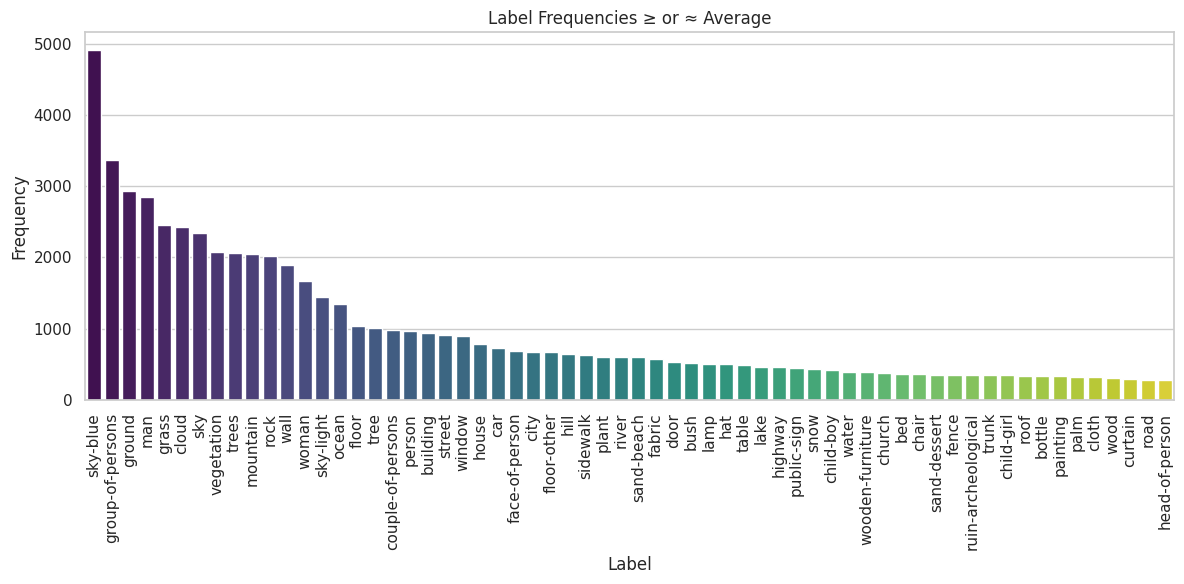

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare DataFrame for plotting
df_selected = labels_gte_avg.reset_index()
df_selected.columns = ['label', 'frequency']

# Set figure size and style
plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Sort by frequency (optional)
df_selected_sorted = df_selected.sort_values(by="frequency", ascending=False)

# Plot
sns.barplot(data=df_selected_sorted, x="label", y="frequency", palette="viridis")

# Formatting
plt.xticks(rotation=90)
plt.title("Label Frequencies ≥ or ≈ Average")
plt.xlabel("Label")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()



In [6]:
import pandas as pd

# Convert average frequency to integer (number of samples per label)
average = int(round(average_frequency))

# Filter label columns to only those selected
selected_label_names = labels_gte_avg.index.tolist()
df_selected_labels = df_labels[selected_label_names]
df_selected = pd.concat([df_metadata, df_selected_labels], axis=1)

subset_rows = pd.DataFrame()

for label in selected_label_names:
    label_rows = df_selected[df_selected[label] == 1]
    if len(label_rows) >= average:
        sampled_rows = label_rows.sample(n=average, random_state=42)
        subset_rows = pd.concat([subset_rows, sampled_rows])

subset_rows = subset_rows.drop_duplicates().reset_index(drop=True)

# Final results
print(f"\nTotal unique images selected: {len(subset_rows)}")
print("\nSample of selected data:")
print(subset_rows.head())

# Save to CSV (adjust path as needed)
subset_rows.to_csv("subset_62_per_label.csv", index=False)



Total unique images selected: 10459

Sample of selected data:
   file_name  bed  bottle  building  bush  car  chair  child-boy  child-girl  \
0  17742.jpg    1       0         0     0    0      0          0           0   
1   1157.jpg    1       0         0     0    0      0          0           0   
2   1107.jpg    1       0         0     0    0      0          0           0   
3   4316.jpg    1       0         0     0    0      0          0           0   
4   1212.jpg    1       0         0     0    0      0          0           0   

   church  ...  tree  trees  trunk  vegetation  wall  water  window  woman  \
0       0  ...     0      0      0           0     1      0       0      0   
1       0  ...     0      0      0           0     1      0       0      0   
2       0  ...     0      0      0           0     1      0       0      0   
3       0  ...     0      0      0           0     1      0       0      0   
4       0  ...     0      0      0           0     1      0       

In [7]:
import os
import pandas as pd
import torch
from torchvision import transforms
from PIL import Image
from tqdm import tqdm

# === Paths and config ===
merged_folder = '/kaggle/working/merged_images'  # Folder containing all merged images
output_dir = 'augmented_images'                  # Folder to save augmented images
augment_factor = 2                               # How many augmented copies per image
image_size = 224                                 # Resize all images to 224x224

# Load metadata (CSV should contain 'file_name' column)
df = pd.read_csv("subset_62_per_label.csv")

# Define augmentation pipeline
augmentation_transforms = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.05),
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# Helper to save image tensors as files
def save_augmented_image(tensor_img, save_path):
    img = transforms.ToPILImage()(tensor_img).convert("RGB")
    img.save(save_path)

# Create output folder
os.makedirs(output_dir, exist_ok=True)

# Track all rows (original + augmented)
augmented_rows = []

print("Applying augmentations...")
for _, row in tqdm(df.iterrows(), total=len(df)):
    image_path = os.path.join(merged_folder, row['file_name'])

    try:
        image = Image.open(image_path).convert("RGB")
    except Exception as e:
        print(f"❌ Failed to open {image_path}: {e}")
        continue

    base_filename = os.path.splitext(row['file_name'])[0]

    # Save resized original image
    image_resized = transforms.Resize((image_size, image_size))(image)
    original_out = f"{base_filename}_orig.jpg"
    image_resized.save(os.path.join(output_dir, original_out))

    # Append metadata for original
    row_copy = row.copy()
    row_copy['file_name'] = original_out
    augmented_rows.append(row_copy)

    # Save augmented versions
    for i in range(augment_factor):
        augmented_img = augmentation_transforms(image)
        aug_filename = f"{base_filename}_aug{i+1}.jpg"
        save_path = os.path.join(output_dir, aug_filename)
        save_augmented_image(augmented_img, save_path)

        row_aug = row.copy()
        row_aug['file_name'] = aug_filename
        augmented_rows.append(row_aug)

# Save new metadata
df_augmented = pd.DataFrame(augmented_rows)
df_augmented.to_csv("augmented_subset.csv", index=False)

print(f"\n✅ Augmentation complete! Total images: {len(df_augmented)}")
print(f"📂 Images saved in: {output_dir}")


Applying augmentations...


100%|██████████| 10459/10459 [07:27<00:00, 23.36it/s]



✅ Augmentation complete! Total images: 31377
📂 Images saved in: augmented_images


In [8]:
import pandas as pd

# ✅ Step 1: Convert average frequency to integer
average = int(round(average_frequency))

# ✅ Step 2: Filter to only selected label columns
selected_label_names = labels_gte_avg.index.tolist()
df_selected_labels = df_labels[selected_label_names]
df_selected = pd.concat([df_metadata, df_selected_labels], axis=1)

# ✅ Step 3: Sample exactly `average` images per label
subset_rows = pd.DataFrame()

for label in selected_label_names:
    label_rows = df_selected[df_selected[label] == 1]
    if len(label_rows) >= average:
        sampled_rows = label_rows.sample(n=average, random_state=42)
        subset_rows = pd.concat([subset_rows, sampled_rows])

# ✅ Step 4: Drop duplicates and reset index
subset_rows = subset_rows.drop_duplicates().reset_index(drop=True)

# ✅ Step 5: Output summary
print(f"\n✅ Total unique images selected: {len(subset_rows)}")
print("\n🔍 Sample of selected data:")
print(subset_rows.head())

# ✅ Step 6: Save to CSV
subset_rows.to_csv("subset_62_per_label.csv", index=False)



✅ Total unique images selected: 10459

🔍 Sample of selected data:
   file_name  bed  bottle  building  bush  car  chair  child-boy  child-girl  \
0  17742.jpg    1       0         0     0    0      0          0           0   
1   1157.jpg    1       0         0     0    0      0          0           0   
2   1107.jpg    1       0         0     0    0      0          0           0   
3   4316.jpg    1       0         0     0    0      0          0           0   
4   1212.jpg    1       0         0     0    0      0          0           0   

   church  ...  tree  trees  trunk  vegetation  wall  water  window  woman  \
0       0  ...     0      0      0           0     1      0       0      0   
1       0  ...     0      0      0           0     1      0       0      0   
2       0  ...     0      0      0           0     1      0       0      0   
3       0  ...     0      0      0           0     1      0       0      0   
4       0  ...     0      0      0           0     1      0   

In [9]:
pip install iterative-stratification

Note: you may need to restart the kernel to use updated packages.


In [10]:
import pandas as pd
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# === Step 1: Load the augmented dataset ===
df = pd.read_csv("augmented_subset.csv")

# === Step 2: Define label columns (exclude metadata) ===
label_columns = df.columns.difference(['file_name', 'Image no'])  # Adjust if other non-label columns exist
df_labels = df[label_columns].astype(int)  # ensure binary format

# === Step 3: Initialize the split column ===
df['split'] = 'unassigned'

# === Step 4: First split: 70% Train, 30% Temp (Val + Test) ===
mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=42)
train_idx, temp_idx = next(mskf.split(df, df_labels))
df.loc[train_idx, 'split'] = 'train'
df_temp = df.iloc[temp_idx].reset_index(drop=True)

# === Step 5: Second split: 15% Val, 15% Test from Temp ===
val_test_labels = df_labels.iloc[temp_idx].reset_index(drop=True)
val_test_splitter = MultilabelStratifiedKFold(n_splits=2, shuffle=True, random_state=42)
val_idx, test_idx = next(val_test_splitter.split(df_temp, val_test_labels))

df_temp.loc[val_idx, 'split'] = 'val'
df_temp.loc[test_idx, 'split'] = 'test'

# === Step 6: Combine final splits ===
df_final = pd.concat([df.loc[train_idx], df_temp], ignore_index=True)

# === Step 7: Save to CSV ===
df_final[df_final['split'] == 'train'].to_csv("train.csv", index=False)
df_final[df_final['split'] == 'val'].to_csv("val.csv", index=False)
df_final[df_final['split'] == 'test'].to_csv("test.csv", index=False)

# === Step 8: Print summary ===
print("\n✅ Dataset split complete!")
print(f"Train: {len(df_final[df_final['split'] == 'train'])}")
print(f"Val  : {len(df_final[df_final['split'] == 'val'])}")
print(f"Test : {len(df_final[df_final['split'] == 'test'])}")



✅ Dataset split complete!
Train: 25123
Val  : 3122
Test : 3132


In [11]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd

# === Your dataset class ===
class MultiLabelImageDataset(Dataset):
    def __init__(self, dataframe, image_dir, label_columns, transform=None):
        self.df = dataframe
        self.image_dir = image_dir
        self.label_columns = label_columns
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_dir, row['file_name'])
        image = Image.open(image_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(row[self.label_columns].values.astype('float32'))
        return image, labels

# === Load data ===
train_df = pd.read_csv("train.csv")
val_df = pd.read_csv("val.csv")
test_df = pd.read_csv("test.csv")

# === Define label columns (same for all splits) ===
label_columns = train_df.columns.difference(['file_name', 'Image no', 'split'])

# === Define image folder (where augmented images are saved) ===
image_dir = 'augmented_images'

# === Define transforms (can differ per split) ===
common_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# === Create Dataset objects ===
train_dataset = MultiLabelImageDataset(train_df, image_dir, label_columns, transform=common_transforms)
val_dataset   = MultiLabelImageDataset(val_df, image_dir, label_columns, transform=common_transforms)
test_dataset  = MultiLabelImageDataset(test_df, image_dir, label_columns, transform=common_transforms)

# === Optional: Wrap with DataLoader ===
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print(f"✅ Loaded: {len(train_dataset)} train, {len(val_dataset)} val, {len(test_dataset)} test samples")


✅ Loaded: 25123 train, 3122 val, 3132 test samples


In [12]:
####ResNetSwinFusion
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights
from timm.models.swin_transformer import swin_tiny_patch4_window7_224

class ResNetSwinFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # === Load pretrained ResNet-50 ===
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # === Early ResNet Layers ===
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2

        # === Intermediate Feature Projection ===
        self.reduce_64_to_32 = nn.Conv2d(64, 32, kernel_size=1)
        self.reduce_256_to_48 = nn.Conv2d(256, 48, kernel_size=1)
        self.reduce_512_to_96 = nn.Conv2d(512, 96, kernel_size=1)

        # === Compress concatenated features ===
        self.compress_fused = nn.Conv2d(176, 96, kernel_size=1)

        # === Swin Transformer Tiny ===
        self.swin = swin_tiny_patch4_window7_224(pretrained=True)
        self.swin.patch_embed = nn.Identity()
        self.swin.pos_drop = nn.Identity()

        # === Classification Head ===
        self.head = nn.Sequential(
            nn.LayerNorm(768),
            nn.Linear(768, num_classes)
        )

        # === Freeze Early ResNet if needed ===
        for param in self.conv1.parameters():
            param.requires_grad = False

    def forward(self, x):
        # ResNet early stages
        x = self.relu(self.bn1(self.conv1(x)))     # (B, 64, 112, 112)
        x = self.maxpool(x)                        # (B, 64, 56, 56)
        early_feat = self.reduce_64_to_32(x)       # (B, 32, 56, 56)

        x1 = self.layer1(x)                        # (B, 256, 56, 56)
        feat1 = self.reduce_256_to_48(x1)          # (B, 48, 56, 56)

        x2 = self.layer2(x1)                       # (B, 512, 28, 28)
        feat2 = self.reduce_512_to_96(x2)          # (B, 96, 28, 28)
        feat2 = F.interpolate(feat2, size=(56, 56), mode='bilinear', align_corners=False)

        # Merge and compress
        fused = torch.cat([early_feat, feat1, feat2], dim=1)  # (B, 176, 56, 56)
        fused = self.compress_fused(fused)                    # (B, 96, 56, 56)

        # Swin expects (B, H, W, C)
        x = fused.permute(0, 2, 3, 1)                         # (B, 56, 56, 96)
        x = self.swin.forward_features(x)                     # (B, 7, 7, 768)
        x = x.mean(dim=(1, 2))                                # Global average pooling

        out = self.head(x)
        return out


# USING SWIN ONLY

In [19]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.metrics import average_precision_score, f1_score
from tqdm import tqdm
import numpy as np
import timm
class SwinClassifier(nn.Module):
    def __init__(self, num_classes):
        super(SwinClassifier, self).__init__()
        self.backbone = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=0)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes)

    def forward(self, x):
        features = self.backbone(x)
        return self.classifier(features)

# USING RSTSWIN ONLY

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNetSwinFusion(num_classes=len(label_columns)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 218MB/s]


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

# USING SWIN

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = SwinClassifier(num_classes=len(label_columns)).to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

# USING CNN+SWIN

In [32]:
import torch
import torch.nn as nn
from timm import create_model

class CustomCNN(nn.Module):
    def __init__(self):
        super(CustomCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.5),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.LeakyReLU(0.1),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.3),
        )
    
    def forward(self, x):
        return self.features(x)

class CNN_Swin_Hybrid(nn.Module):
    def __init__(self, num_classes):
        super(CNN_Swin_Hybrid, self).__init__()
        self.cnn = CustomCNN()
        self.swin = create_model("swin_tiny_patch4_window7_224", pretrained=True, num_classes=num_classes)
        
        # Optional: if cnn output size ≠ 3-channel input, add 1x1 conv to reshape channels
        self.channel_adapter = nn.Conv2d(64, 3, kernel_size=1)

    def forward(self, x):
        x = self.cnn(x)  # Output: (B, 64, H/4, W/4)
        x = self.channel_adapter(x)  # Make it (B, 3, H/4, W/4) for Swin
        x = nn.functional.interpolate(x, size=(224, 224))  # Resize for Swin input
        return self.swin(x)


# USING RESNET

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import resnet50, ResNet50_Weights

class ResNetOnlyFusion(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # === Load pretrained ResNet-50 ===
        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

        # === Early ResNet Layers ===
        self.conv1 = resnet.conv1
        self.bn1 = resnet.bn1
        self.relu = resnet.relu
        self.maxpool = resnet.maxpool
        self.layer1 = resnet.layer1
        self.layer2 = resnet.layer2
        self.layer3 = resnet.layer3
        self.layer4 = resnet.layer4

        # === Feature Reductions ===
        self.reduce_64_to_32 = nn.Conv2d(64, 32, kernel_size=1)
        self.reduce_256_to_48 = nn.Conv2d(256, 48, kernel_size=1)
        self.reduce_512_to_64 = nn.Conv2d(512, 64, kernel_size=1)
        self.reduce_1024_to_96 = nn.Conv2d(1024, 96, kernel_size=1)

        # === Compress concatenated features ===
        self.compress_fused = nn.Conv2d(240, 128, kernel_size=1)

        # === Classification Head ===
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(128, num_classes)
        )

        # Optional: Freeze early layers
        for param in self.conv1.parameters():
            param.requires_grad = False

    def forward(self, x):
        # Initial Layers
        x = self.relu(self.bn1(self.conv1(x)))        # (B, 64, 112, 112)
        x = self.maxpool(x)                           # (B, 64, 56, 56)
        feat0 = self.reduce_64_to_32(x)               # (B, 32, 56, 56)

        x1 = self.layer1(x)                           # (B, 256, 56, 56)
        feat1 = self.reduce_256_to_48(x1)             # (B, 48, 56, 56)

        x2 = self.layer2(x1)                          # (B, 512, 28, 28)
        feat2 = self.reduce_512_to_64(x2)             # (B, 64, 28, 28)
        feat2 = F.interpolate(feat2, size=(56, 56), mode='bilinear', align_corners=False)

        x3 = self.layer3(x2)                          # (B, 1024, 14, 14)
        feat3 = self.reduce_1024_to_96(x3)            # (B, 96, 14, 14)
        feat3 = F.interpolate(feat3, size=(56, 56), mode='bilinear', align_corners=False)

        # Fuse and compress
        fused = torch.cat([feat0, feat1, feat2, feat3], dim=1)  # (B, 240, 56, 56)
        fused = self.compress_fused(fused)                      # (B, 128, 56, 56)

        # Classification
        out = self.classifier(fused)                            # (B, num_classes)
        return out


# TO SET UP THE MODEL

In [33]:
##USING CNN + SWIN
import torch.optim as optim
# Automatically select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_Swin_Hybrid(num_classes=len(label_columns)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)


In [14]:
##USING RESNET
import torch.optim as optim
# Automatically select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNetOnlyFusion(num_classes=len(label_columns)).to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 203MB/s]


In [14]:
from tqdm import tqdm
from sklearn.metrics import average_precision_score, f1_score, accuracy_score
import numpy as np
import torch

num_epochs = 30
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_maps, val_maps = [], []
train_f1s, val_f1s = [], []

best_val_map = -np.inf
best_train_map = -np.inf
patience = 5
patience_counter = 0
best_model_state = None
best_val_acc = 0
best_val_f1 = 0
best_epoch = 0

best_train_acc = 0
best_train_f1 = 0
best_train_epoch = 0

for epoch in range(num_epochs):
    # -------- Training --------
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0
    all_train_preds = []
    all_train_labels = []

    for images, labels in tqdm(train_loader, desc=f"[Train] Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        total_correct += (preds == labels).sum().item()
        total_samples += labels.numel()

        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(labels.cpu().numpy())

    # Compute training metrics
    avg_loss = total_loss / len(train_loader)
    acc = total_correct / total_samples
    train_preds = np.vstack(all_train_preds)
    train_labels = np.vstack(all_train_labels)
    train_map = average_precision_score(train_labels, train_preds, average='macro')
    train_f1 = f1_score(train_labels, train_preds, average='macro', zero_division=0)

    train_losses.append(avg_loss)
    train_accuracies.append(acc)
    train_maps.append(train_map)
    train_f1s.append(train_f1)

    print(f"[Train] Epoch {epoch+1}: Loss={avg_loss:.4f} | Acc={acc:.4f} | mAP={train_map:.4f} | F1={train_f1:.4f}")

    # Save best training stats
    if train_map > best_train_map:
        best_train_map = train_map
        best_train_acc = acc
        best_train_f1 = train_f1
        best_train_epoch = epoch + 1

    # -------- Validation --------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_samples = 0
    all_val_preds = []
    all_val_labels = []

    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f"[Valid] Epoch {epoch+1}/{num_epochs}"):
            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            preds = (outputs.sigmoid() > 0.3).float()
            val_correct += (preds == labels).sum().item()
            val_samples += labels.numel()

            all_val_preds.append(preds.cpu().numpy())
            all_val_labels.append(labels.cpu().numpy())

    avg_val_loss = val_loss / len(val_loader)
    val_acc = val_correct / val_samples
    val_preds = np.vstack(all_val_preds)
    val_labels = np.vstack(all_val_labels)
    val_map = average_precision_score(val_labels, val_preds, average='macro')
    val_f1 = f1_score(val_labels, val_preds, average='macro', zero_division=0)

    val_losses.append(avg_val_loss)
    val_accuracies.append(val_acc)
    val_maps.append(val_map)
    val_f1s.append(val_f1)

    print(f"[Val]   Epoch {epoch+1}: Loss={avg_val_loss:.4f} | Acc={val_acc:.4f} | mAP={val_map:.4f} | F1={val_f1:.4f}")

    # -------- Early Stopping Check --------
    if val_map > best_val_map:
        best_val_map = val_map
        best_val_acc = val_acc
        best_val_f1 = val_f1
        best_epoch = epoch + 1
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        print(f"--> No improvement. Patience: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Early stopping triggered.")
        break

# ========= Final Performance Summary =========
print("\n========== Best Validation Performance ==========")
print(f"Epoch        : {best_epoch}")
print(f"Best mAP     : {best_val_map:.4f}")
print(f"Best Accuracy: {best_val_acc:.4f}")
print(f"Best F1-Score: {best_val_f1:.4f}")

print("\n========== Best Training Performance ==========")
print(f"Epoch        : {best_train_epoch}")
print(f"Best mAP     : {best_train_map:.4f}")
print(f"Best Accuracy: {best_train_acc:.4f}")
print(f"Best F1-Score: {best_train_f1:.4f}")

[Train] Epoch 1/30: 100%|██████████| 786/786 [04:38<00:00,  2.82it/s]


[Train] Epoch 1: Loss=0.2106 | Acc=0.9347 | mAP=0.0751 | F1=0.0264


[Valid] Epoch 1/30: 100%|██████████| 98/98 [00:12<00:00,  8.03it/s]


[Val]   Epoch 1: Loss=0.1894 | Acc=0.9325 | mAP=0.1062 | F1=0.1128


[Train] Epoch 2/30: 100%|██████████| 786/786 [04:37<00:00,  2.83it/s]


...

[Val]   Epoch 29: Loss=0.0736 | Acc=0.9805 | mAP=0.7188 | F1=0.8380
--> No improvement. Patience: 1/5


[Train] Epoch 30/30: 100%|██████████| 786/786 [04:37<00:00,  2.83it/s]


[Train] Epoch 30: Loss=0.0086 | Acc=0.9972 | mAP=0.9555 | F1=0.9766


[Valid] Epoch 30/30: 100%|██████████| 98/98 [00:12<00:00,  8.09it/s]

[Val]   Epoch 30: Loss=0.0692 | Acc=0.9816 | mAP=0.7307 | F1=0.8462
--> No improvement. Patience: 2/5

========== Best Validation Performance ==========
Epoch        : 28
Best mAP     : 0.7318
Best Accuracy: 0.9812
Best F1-Score: 0.8482

========== Best Training Performance ==========
Epoch        : 29
Best mAP     : 0.9591
Best Accuracy: 0.9974
Best F1-Score: 0.9785


In [15]:
# -------- Testing --------
model.eval()
test_loss = 0
test_correct = 0
test_samples = 0
all_test_preds = []
all_test_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="[Test]"):
        images = images.to(device)
        labels = labels.to(device).float()

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item()
        preds = (outputs.sigmoid() > 0.5).float()
        test_correct += (preds == labels).sum().item()
        test_samples += labels.numel()

        all_test_preds.append(preds.cpu().numpy())
        all_test_labels.append(labels.cpu().numpy())

test_preds = np.vstack(all_test_preds)
test_labels = np.vstack(all_test_labels)

test_acc = test_correct / test_samples
test_map = average_precision_score(test_labels, test_preds, average='macro')
test_f1 = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print(f"[Test] Loss: {test_loss / len(test_loader):.4f} | Acc: {test_acc:.4f} | mAP: {test_map:.4f} | F1: {test_f1:.4f}")

[Test]: 100%|██████████| 98/98 [00:12<00:00,  8.05it/s]


[Test] Loss: 0.0681 | Acc: 0.9823 | mAP: 0.7302 | F1: 0.8420


In [17]:
from sklearn.metrics import classification_report

# Classification report
report = classification_report(
    test_labels,
    (test_preds > 0.5).astype(int),
    target_names=label_columns,
    zero_division=0
)

print("Classification Report:\n")
print(report)


Classification Report:

                    precision    recall  f1-score   support

               bed       0.98      0.92      0.95       105
            bottle       0.90      0.72      0.80        96
          building       0.89      0.84      0.87       203
              bush       0.86      0.69      0.77       124
               car       0.91      0.84      0.87       178
             chair       0.95      0.66      0.78       105
         child-boy       0.82      0.74      0.78       108
        child-girl       0.82      0.73      0.78        94
            church       0.91      0.96      0.93       103
              city       0.94      0.89      0.92       133
             cloth       0.95      0.57      0.71        93
             cloud       0.93      0.85      0.89       463
 couple-of-persons       0.87      0.69      0.77       224
           curtain       0.94      0.85      0.89        87
              door       0.88      0.81      0.85       145
            fab

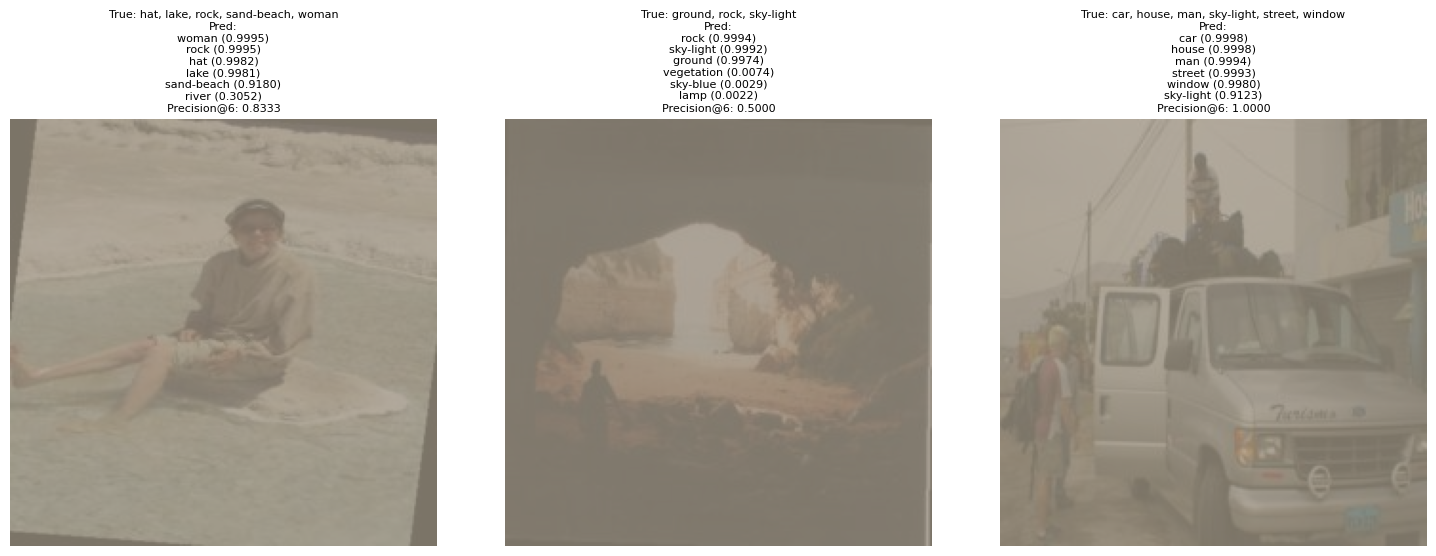


Average Precision@6: 0.611
Average Recall@6: 0.920
Average F1@6: 0.700


In [23]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
from torchvision import transforms

# === Inverse normalization (for ImageNet pretrained models) ===
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])],
    std=[1/s for s in [0.229, 0.224, 0.225]]
)

# === Mapping from index to label ===
idx_to_label = {i: label for i, label in enumerate(label_columns)}

# === Visualize N random samples from the test dataset ===
test_samples = list(test_dataset)
num_to_show = 3
top_k = 6  # You can set Precision@k here

random_samples = random.sample(test_samples, num_to_show)

plt.figure(figsize=(15, 10))
model.eval()

for i, (image, true_labels) in enumerate(random_samples):
    image_input = image.unsqueeze(0).to(device)
    true_labels = true_labels.numpy()

    with torch.no_grad():
        outputs = model(image_input)
        probs = outputs.sigmoid().cpu().squeeze()

    # === Top-k predicted labels and scores ===
    topk_probs, topk_indices = torch.topk(probs, top_k)
    ranked_preds = [f"{idx_to_label[idx.item()]} ({topk_probs[j].item():.4f})"
                    for j, idx in enumerate(topk_indices)]

    # === Ground truth label names ===
    true_lbls = [idx_to_label[i] for i in range(len(true_labels)) if true_labels[i] == 1]

    # === Precision@k ===
    true_indices = set(np.where(true_labels == 1)[0])
    predicted_topk = set(topk_indices.cpu().numpy())
    correct_preds = predicted_topk.intersection(true_indices)
    precision_at_k = len(correct_preds) / top_k

    # === Convert image to display format ===
    img_disp = inv_normalize(image).permute(1, 2, 0).numpy()
    img_disp = np.clip(img_disp, 0, 1)

    # === Plot ===
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_disp)
    plt.axis('off')
    plt.title(
        f"True: {', '.join(true_lbls)}\n"
        f"Pred:\n" + "\n".join(ranked_preds) + 
        f"\nPrecision@{top_k}: {precision_at_k:.4f}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

# === Compute Average Precision@k over the entire test set ===
# === Compute Average Precision@k, Recall@k, and F1@k ===
total_precision = 0
total_recall = 0
total_f1 = 0
num_samples = 0
top_k = 6 # Change this for Precision@1, @3, @5 etc.

model.eval()
for image, true_labels in test_dataset:
    image_input = image.unsqueeze(0).to(device)
    true_labels = true_labels.numpy()

    with torch.no_grad():
        outputs = model(image_input)
        probs = outputs.sigmoid().cpu().squeeze()

    topk_probs, topk_indices = torch.topk(probs, top_k)

    true_indices = set(np.where(true_labels == 1)[0])
    predicted_topk = set(topk_indices.cpu().numpy())

    # Correct predictions
    correct_preds = predicted_topk.intersection(true_indices)

    # Precision@k
    precision_at_k = len(correct_preds) / top_k

    # Recall@k
    recall_at_k = len(correct_preds) / len(true_indices) if len(true_indices) > 0 else 0

    # F1@k
    if precision_at_k + recall_at_k > 0:
        f1_at_k = 2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k)
    else:
        f1_at_k = 0

    total_precision += precision_at_k
    total_recall += recall_at_k
    total_f1 += f1_at_k
    num_samples += 1

average_precision_at_k = total_precision / num_samples
average_recall_at_k = total_recall / num_samples
average_f1_at_k = total_f1 / num_samples

print(f"\nAverage Precision@{top_k}: {average_precision_at_k:.3f}")
print(f"Average Recall@{top_k}: {average_recall_at_k:.3f}")
print(f"Average F1@{top_k}: {average_f1_at_k:.3f}")


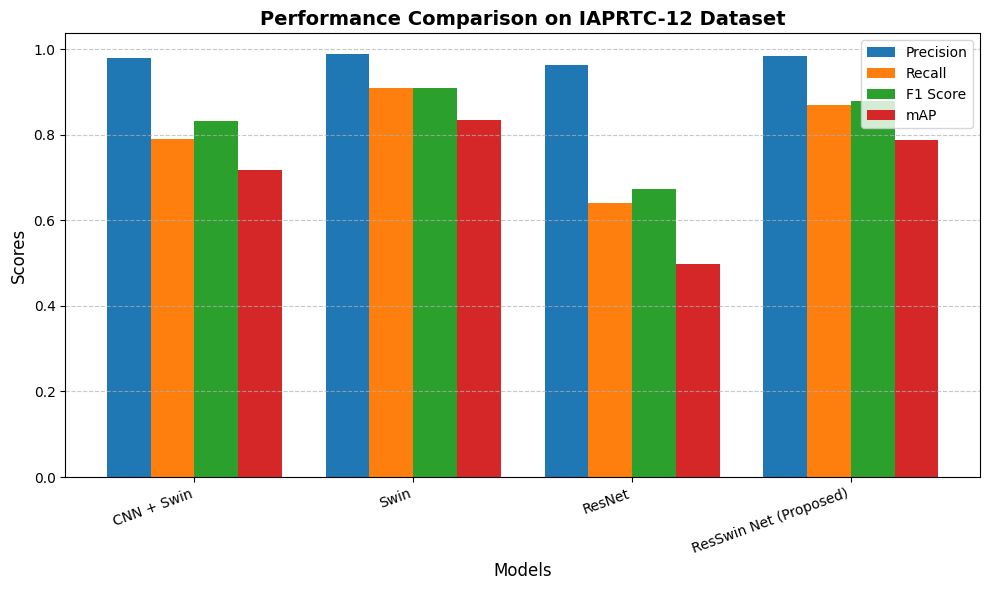

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# Models
models = ["CNN + Swin", "Swin", "ResNet", "ResSwin Net (Proposed)"]

# Metrics
precision = [0.9801, 0.9882, 0.9634, 0.9856]
recall = [0.79, 0.91, 0.64, 0.87]
f1_score = [0.8333, 0.9093, 0.6734, 0.88]
map_score = [0.7172, 0.836, 0.4992, 0.7885]

# Combine metrics
metrics = [precision, recall, f1_score, map_score]
metric_names = ["Precision", "Recall", "F1 Score", "mAP"]

# Plot setup
x = np.arange(len(models))  # the label locations
width = 0.2  # bar width

fig, ax = plt.subplots(figsize=(10,6))

# Plot each metric
for i, metric in enumerate(metrics):
    ax.bar(x + i*width - 1.5*width, metric, width, label=metric_names[i])

# Labels & styling
ax.set_xlabel("Models", fontsize=12)
ax.set_ylabel("Scores", fontsize=12)
ax.set_title("Performance Comparison on IAPRTC-12 Dataset", fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=20, ha="right")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.show()
